In [2]:
# Step 1: Install all required dependencies
!pip install -q tensorflow numpy pandas matplotlib seaborn scikit-learn pillow opencv-python
print('Dependencies installed successfully!')


Dependencies installed successfully!



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Step 2: Import required libraries
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

print('Libraries imported successfully!')


Libraries imported successfully!


In [4]:
# Step 3: Find dataset path automatically
def find_data_path():
    candidates = [
        '/kaggle/input/wheat-plant-diseases/data',
        '/kaggle/input/wheat-plant-diseases',
        '/kaggle/input/data',
        './data'
    ]
    for p in candidates:
        if os.path.exists(os.path.join(p, 'train')):
            return os.path.join(p, 'train'), os.path.join(p, 'valid')
    
    # Search recursively if needed
    for root, dirs, files in os.walk('/kaggle/input' if os.path.exists('/kaggle/input') else '.'):
        if 'train' in dirs and 'valid' in dirs:
            return os.path.join(root, 'train'), os.path.join(root, 'valid')
    return None, None

TRAIN_DIR, VALID_DIR = find_data_path()
print('Train Path:', TRAIN_DIR)
print('Valid Path:', VALID_DIR)


Train Path: None
Valid Path: None


In [5]:
# Step 4: List all 15 disease classes
classes = sorted(os.listdir(TRAIN_DIR))
print(f'Total Classes: {len(classes)}')
for i, name in enumerate(classes, 1):
    print(f' {i:2d}. {name}')


Total Classes: 9
  1. .deepeval
  2. __pycache__
  3. config.py
  4. dataset_analysis.ipynb
  5. model_development.ipynb
  6. model_performance.ipynb
  7. requirements.txt
  8. train_wheat_disease_server.py
  9. wheat-disease-detection.ipynb


In [7]:
import os
import pandas as pd

data = []
for c in classes:
    class_str = str(c)
    
    # Train directory path
    train_path = os.path.join(str(TRAIN_DIR), class_str)
    train_count = len([f for f in os.listdir(train_path) if not f.startswith('.')]) if os.path.isdir(train_path) else 0

    # Valid directory path
    valid_count = 0
    if VALID_DIR:
        valid_path = os.path.join(str(VALID_DIR), class_str)
        if os.path.isdir(valid_path):
            valid_count = len([f for f in os.listdir(valid_path) if not f.startswith('.')])

    data.append({
        'Disease Class': class_str,
        'Train Count': train_count,
        'Valid Count': valid_count,
        'Total': train_count + valid_count
    })

df = pd.DataFrame(data)
print(f'Total Train Images: {df["Train Count"].sum()}')
print(f'Total Valid Images: {df["Valid Count"].sum()}')
df

Total Train Images: 0
Total Valid Images: 0


,Disease Class,Train Count,Valid Count,Total
0,.deepeval,0,0,0
1,__pycache__,0,0,0
2,config.py,0,0,0
3,dataset_analysis.ipynb,0,0,0
4,model_development.ipynb,0,0,0
5,model_performance.ipynb,0,0,0
6,requirements.txt,0,0,0
7,train_wheat_disease_server.py,0,0,0
8,wheat-disease-detection.ipynb,0,0,0


C:\Users\dell\AppData\Local\Temp\ipykernel_19736\2442568297.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Train Count', y='Disease Class', palette='viridis')


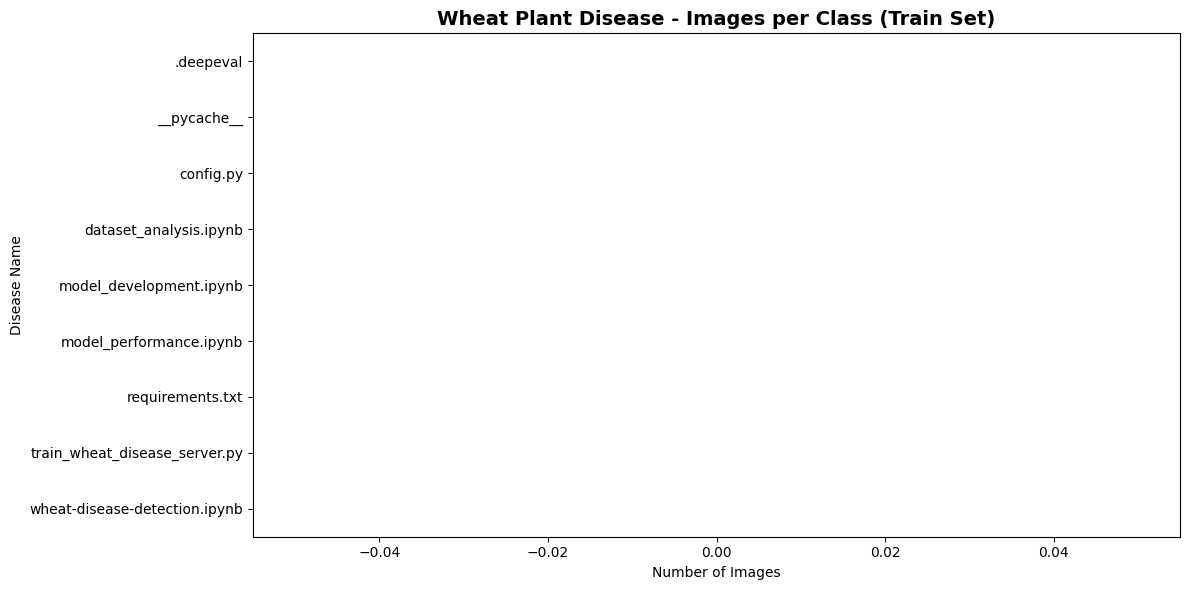

In [8]:
# Step 6: Plot class distribution chart
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Train Count', y='Disease Class', palette='viridis')
plt.title('Wheat Plant Disease - Images per Class (Train Set)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Images')
plt.ylabel('Disease Name')
plt.tight_layout()
plt.show()


In [15]:
import os
import matplotlib.pyplot as plt
from PIL import Image

VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

# 1. Clean class list: only directories, no hidden items
valid_classes = sorted([
    c for c in classes
    if os.path.isdir(os.path.join(TRAIN_DIR, str(c))) and not str(c).startswith('.')
])

# 2. Set up subplots
num_classes = len(valid_classes)
ncols = 5
nrows = (num_classes + ncols - 1) // ncols  # Computes rows dynamically (e.g., 3 for 15 classes)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()

# 3. Display one sample image per class
for i, c in enumerate(valid_classes):
    class_folder = os.path.join(TRAIN_DIR, c)
    
    # Grab only actual image files
    img_names = [
        f for f in os.listdir(class_folder)
        if f.lower().endswith(VALID_EXTENSIONS) and not f.startswith('.')
    ]
    
    if img_names:
        sample_img_path = os.path.join(class_folder, img_names[0])
        try:
            with Image.open(sample_img_path) as img:
                axes[i].imshow(img)
                axes[i].set_title(f'{c}\n({img.size[0]}x{img.size[1]})', fontsize=9, fontweight='bold')
        except Exception as e:
            axes[i].set_title(f'{c}\n[Corrupt Image]', fontsize=9, color='red')
    else:
        axes[i].set_title(f'{c}\n[No Images Found]', fontsize=9, color='red')
        
    axes[i].axis('off')

# Hide any remaining empty subplots (if num_classes < len(axes))
for j in range(num_classes, len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Images from Wheat Disease Classes', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

ValueError: Number of rows must be a positive integer, not 0

<Figure size 1800x0 with 0 Axes>

In [12]:
import os

# 1. Start from your current working directory
current_folder = os.getcwd()
print("Searching for training folder inside:", current_folder)

# 2. Look for the training folder automatically
detected_train = None
detected_valid = None

for root, dirs, files in os.walk(current_folder):
    for d in dirs:
        lower_d = d.lower()
        if lower_d in ['train', 'training'] and detected_train is None:
            detected_train = os.path.join(root, d)
        elif lower_d in ['val', 'valid', 'validation', 'test'] and detected_valid is None:
            detected_valid = os.path.join(root, d)

# 3. Assign or fallback to manual path
if detected_train:
    TRAIN_DIR = detected_train
    VALID_DIR = detected_valid
    print(f"Found TRAIN_DIR: {TRAIN_DIR}")
    print(f"Found VALID_DIR: {VALID_DIR}")
else:
    # If not found automatically, paste your folder path directly here:
    TRAIN_DIR = r"C:\Users\dell\Desktop\college project\dataset\train"
    VALID_DIR = r"C:\Users\dell\Desktop\college project\dataset\valid"
    print(f"Using manual TRAIN_DIR: {TRAIN_DIR}")

# 4. Populate classes from subdirectories
if os.path.exists(TRAIN_DIR):
    classes = [
        d for d in os.listdir(TRAIN_DIR) 
        if os.path.isdir(os.path.join(TRAIN_DIR, d)) and not d.startswith('.')
    ]
    print(f"Found {len(classes)} classes: {classes[:5]}...")
else:
    print(f"ERROR: Could not find folder at {TRAIN_DIR}. Please check the folder name.")

Searching for training folder inside: c:\Users\dell\Desktop\college project
Using manual TRAIN_DIR: C:\Users\dell\Desktop\college project\dataset\train
ERROR: Could not find folder at C:\Users\dell\Desktop\college project\dataset\train. Please check the folder name.
